<a href="https://colab.research.google.com/github/garvitupdy/customer-cluster/blob/main/customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("Shopping Mall Customer Segmentation Data .csv")
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [ ]:
df.shape

(15079, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB


In [ ]:
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
continuos = df.select_dtypes(include="number")
continuos

,Age,Annual Income,Spending Score
0,30,151479,89
1,58,185088,95
2,62,70912,76
3,23,55460,57
4,24,153752,76
...,...,...,...
15074,29,97723,30
15075,22,73361,74
15076,18,112337,48
15077,26,94312,5


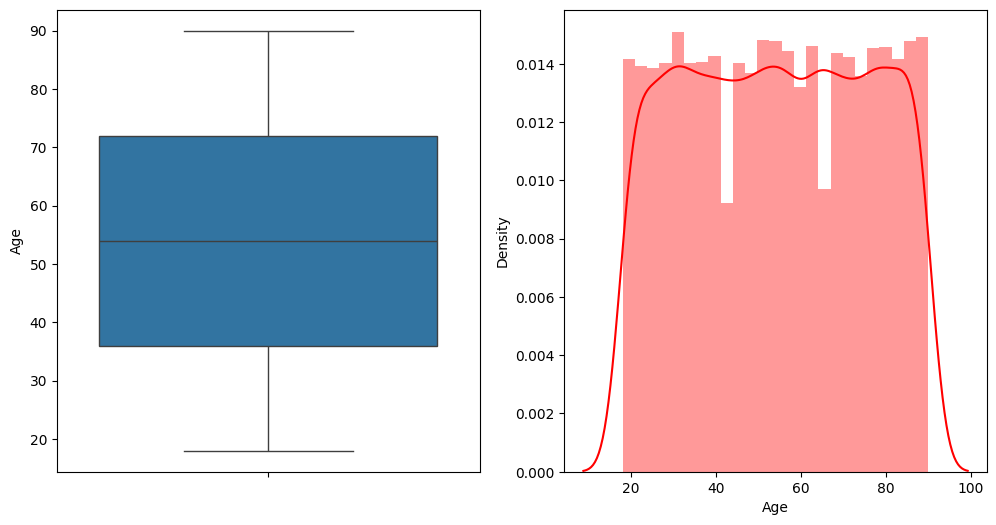

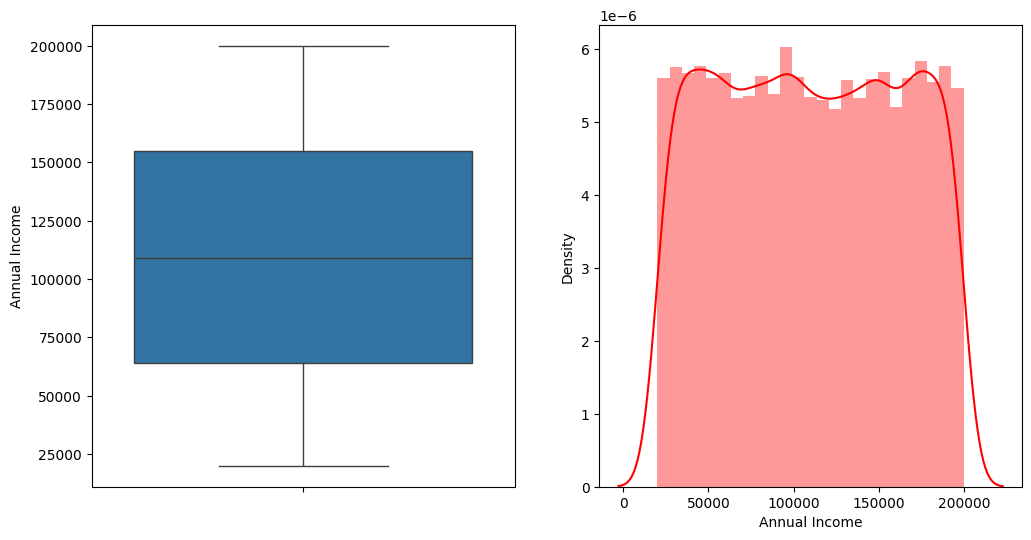

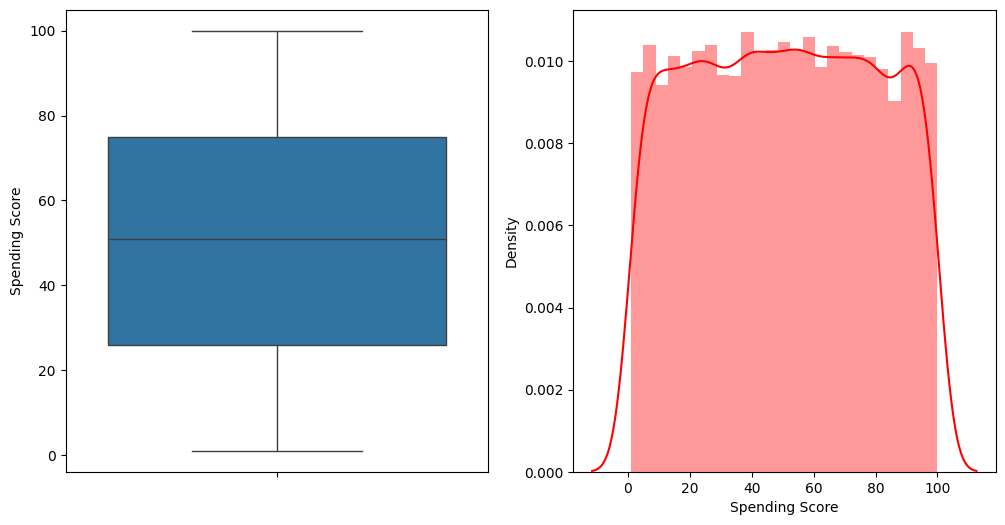

In [ ]:
for con in continuos:
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    sns.boxplot(df[con])
    plt.subplot(1,2,2)
    sns.distplot(df[con], color= "Red")
    plt.show()


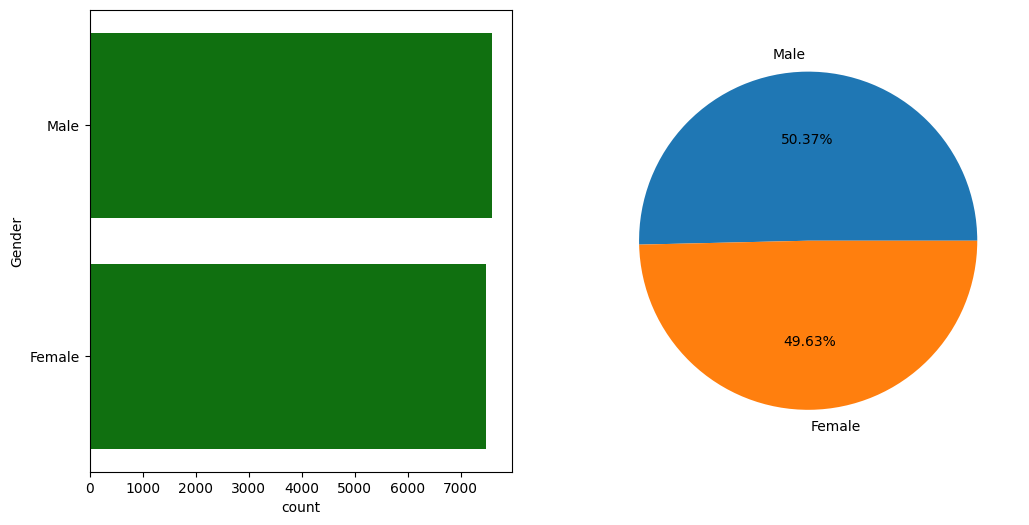

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(df["Gender"], color = 'green')
plt.subplot(1,2,2)
plt.pie(df["Gender"].value_counts(), labels=df["Gender"].value_counts().index, autopct="%.2f%%")
plt.show()

   Gender  Annual Income
0  Female  109902.799572
1    Male  109585.298749


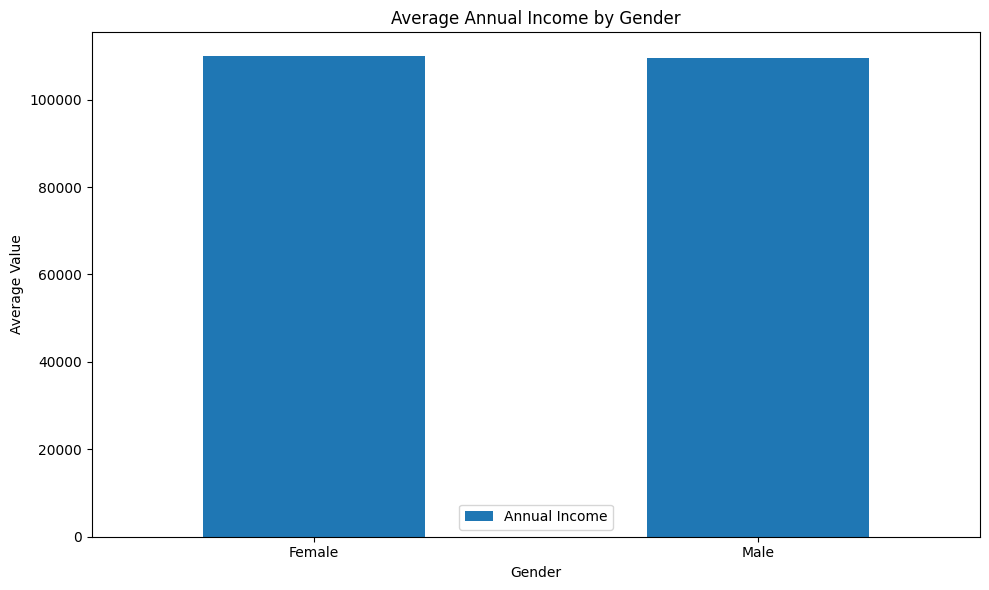

In [ ]:
grouped_annual_income = df.groupby("Gender")["Annual Income",].mean().reset_index()
print(grouped_annual_income)
plt.figure(figsize=(10, 6))
grouped_annual_income.plot(
    kind="bar",
    x="Gender",
    y=["Annual Income", ],
    ax=plt.gca()
)
plt.title("Average Annual Income by Gender")
plt.ylabel("Average Value")
plt.xlabel("Gender")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

   Gender  Spending Score
0  Female       50.397648
1    Male       50.782752


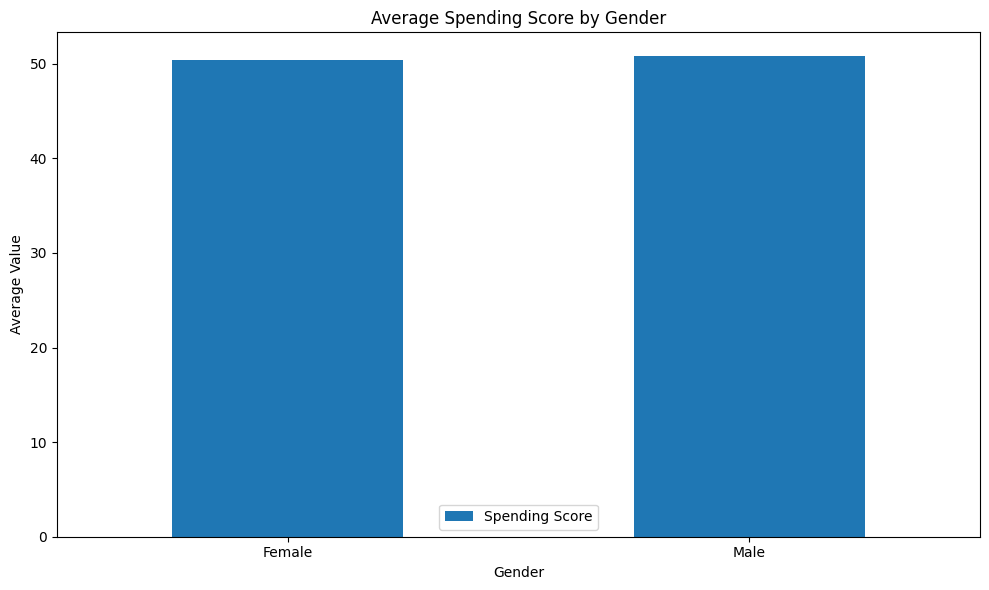

In [ ]:
grouped_spending_score = df.groupby("Gender")["Spending Score",].mean().reset_index()
print(grouped_spending_score)
plt.figure(figsize=(10, 6))
grouped_spending_score.plot(
    kind="bar",
    x="Gender",
    y=["Spending Score", ],
    ax=plt.gca()
)
plt.title("Average Spending Score by Gender")
plt.ylabel("Average Value")
plt.xlabel("Gender")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

   Gender        Age
0  Female  54.148316
1    Male  54.234233


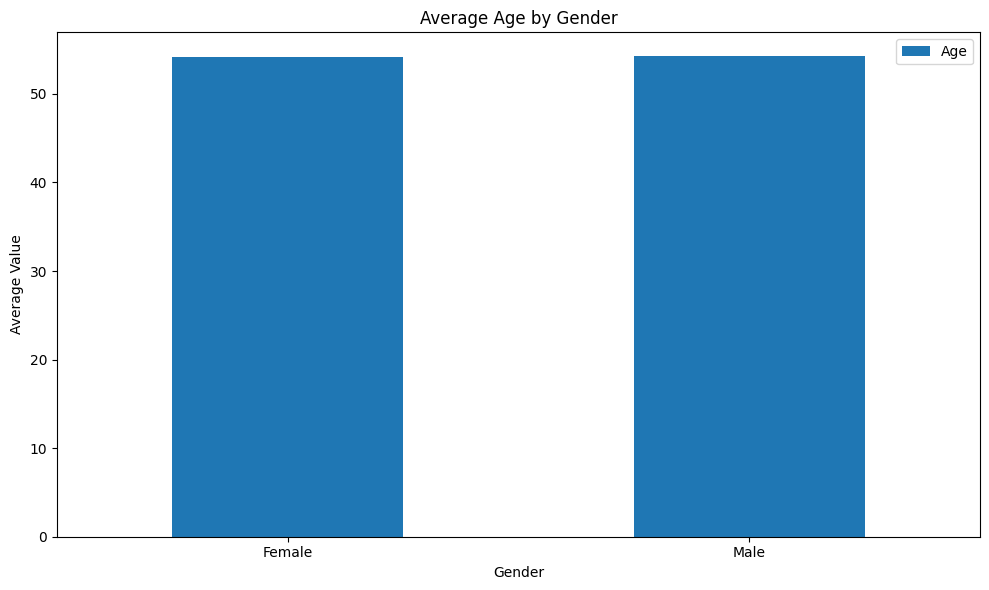

In [ ]:
average_age = df.groupby("Gender")["Age",].mean().reset_index()
print(average_age)
plt.figure(figsize=(10, 6))
average_age.plot(
    kind="bar",
    x="Gender",
    y=["Age", ],
    ax=plt.gca()
)
plt.title("Average Age by Gender")
plt.ylabel("Average Value")
plt.xlabel("Gender")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(["Customer ID"], axis=1)
df.head()

,Age,Gender,Annual Income,Spending Score
0,30,Male,151479,89
1,58,Female,185088,95
2,62,Female,70912,76
3,23,Male,55460,57
4,24,Male,153752,76


In [ ]:
df = pd.get_dummies(df, columns=["Gender"])
df.head()

,Age,Annual Income,Spending Score,Gender_Female,Gender_Male
0,30,151479,89,False,True
1,58,185088,95,True,False
2,62,70912,76,True,False
3,23,55460,57,False,True
4,24,153752,76,False,True


In [ ]:
df["Gender_Female"] = df["Gender_Female"].astype(int)
df["Gender_Male"] = df["Gender_Male"].astype(int)
df.head()

,Age,Annual Income,Spending Score,Gender_Female,Gender_Male
0,30,151479,89,0,1
1,58,185088,95,1,0
2,62,70912,76,1,0
3,23,55460,57,0,1
4,24,153752,76,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)
x_scaled

array([[-1.14551615,  0.79881267,  1.33705873, -0.99266566,  0.99266566],
       [ 0.18033514,  1.44207552,  1.54592857,  1.00738853, -1.00738853],
       [ 0.36974247, -0.74320756,  0.88450743,  1.00738853, -1.00738853],
       ...,
       [-1.71373813,  0.04965041, -0.09021845,  1.00738853, -1.00738853],
       [-1.33492347, -0.2953409 , -1.58711891,  1.00738853, -1.00738853],
       [-1.6663863 , -0.60668478, -1.69155383, -0.99266566,  0.99266566]])

In [ ]:
from sklearn.cluster import KMeans
K_range = range(1, 11)

inertia = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)


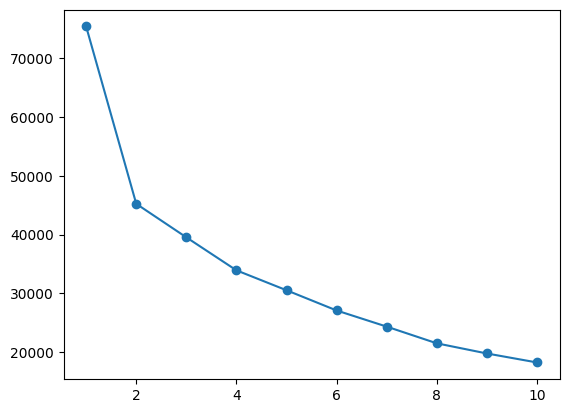

In [ ]:

plt.plot(K_range, inertia, marker='o')

In [ ]:

kmeans_final = KMeans(n_clusters=8, random_state=42)


In [ ]:
cluster_labels = kmeans_final.fit_predict(x_scaled)
df['cluster_labels'] = cluster_labels
df.head()

,Age,Annual Income,Spending Score,Gender_Female,Gender_Male,cluster_labels
0,30,151479,89,0,1,3
1,58,185088,95,1,0,2
2,62,70912,76,1,0,4
3,23,55460,57,0,1,6
4,24,153752,76,0,1,3


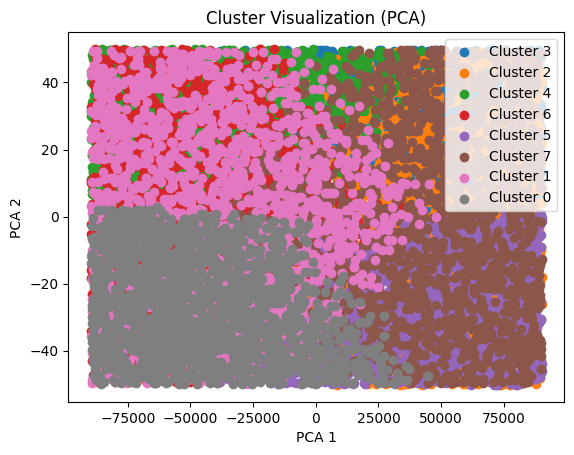

In [ ]:
from sklearn.decomposition import PCA

features = df.drop('cluster_labels', axis=1)

pca = PCA(n_components=2)
components = pca.fit_transform(features)

plt.figure()

for cluster in df['cluster_labels'].unique():
    plt.scatter(
        components[df['cluster_labels']==cluster,0],
        components[df['cluster_labels']==cluster,1],
        label=f'Cluster {cluster}'
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.title('Cluster Visualization (PCA)')
plt.show()